# Financial Status Prediction Using the 2024 FinAccess Household Survey

## Background

Financial inclusion plays a critical role in improving economic wellbeing and resilience among households. Understanding the factors associated with financial improvement or deterioration can help policymakers, financial institutions, and development organizations design targeted interventions.

## Objective

The objective of this project is to develop a machine learning model capable of predicting whether a Kenyan adult's financial situation has:

- Improved
- Stayed the same
- Worsened

using demographic, economic, behavioural, and financial inclusion indicators from the 2024 FinAccess Household Survey.

## Analytical Questions

This project seeks to answer the following questions:

1. What characteristics are associated with improved financial outcomes?
2. Which factors contribute most strongly to worsening financial conditions?
3. Which variables are most important for predicting financial status?
4. What recommendations can be derived from the findings?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

financialaccess = pd.read_excel('/kaggle/input/datasets/guyokana/financialaccess2024xlsx/finaccess2024_datasprint.xlsx')

print(financialaccess.shape, "\n")
print(financialaccess.info())

(20871, 28) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   county                 20871 non-null  object
 1   location_type          20871 non-null  object
 2   Sex                    20871 non-null  object
 3   Age                    20871 non-null  object
 4   household_size         20871 non-null  int64 
 5   education_level        20871 non-null  object
 6   marital_status         20871 non-null  object
 7   monthly_income         20871 non-null  int64 
 8   Savings_formal         20871 non-null  object
 9   Savings_informal       20871 non-null  object
 10  Loan_formal            20871 non-null  object
 11  Loan_informal          20871 non-null  object
 12  defaulted              20871 non-null  object
 13  formal_service_use     20871 non-null  object
 14  mobile_money_access    20871 non-null  object
 15  barri

The dataset contains 20.871 respondents and 28 variables, with every row representing one Kenyan adult surveyed in the FinAccess 2024 study. 

The variables cover several dimensions:

- Demographics
- Household characteristics
- Income
- Financial behaviour
- Financial inclusion
- Financial health indicators
- Financial outcomes

In [2]:
financialaccess.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
county,20871,47,Meru,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,20871,2,Rural,13549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,20871,2,Female,12326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20871,6,26-35,5361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,20871.0,NaN,NaN,NaN,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
education_level,20871,13,"""Secondary completed """,4113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,20871,6,Married/Living with partner,11432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,20871.0,NaN,NaN,NaN,9702.77428,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
Savings_formal,20871,2,Non-usage,11635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Savings_informal,20871,2,Non-usage,16031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Description

* The dataset contains 20,871 respondents and 28 variables (3 numeric, 25 categorical), with no missing values except `barriers_bank` (15,137 non-null, ~27.5% missing).

* Respondents span all 47 counties, are predominantly rural (13,549, ~65%) and female (12,326, ~59%), with the 26–35 age band most common (5,361). Average household size is 4.2 (median 4, range 1–20).

* Monthly income is highly skewed: median KES 5,000 vs. mean KES 9,703 (range 100–200,000), reflecting a small number of high earners.

* Financial behaviour is dominated by non-usage of formal and informal savings/loans (e.g., informal savings non-usage at 16,031, ~77%), despite high formal service use overall (18,224, ~87%). Mobile money access (17,868, ~86%) and ownership (16,888, ~81%) are both widespread.

* The target, `financial_status`, has three classes: Worsened (10,981, 52.6%), Stayed the same (26.9%), Improved (20.5%) — a moderately imbalanced target.

* `fl_score` (financial literacy) is mostly "Two correct" (8,580), and `prodsum1` (product count) averages 3.94 (range 0–22). Where `barriers_bank` is reported, "Affordability" dominates (10,223 of 15,137).

* Most respondents are married or living with a partner (11,432), and "Secondary completed" is the most common education level (4,113) among 13 categories.

* Loan usage mirrors the savings pattern, with non-usage dominant for both formal (12,340, ~59%) and informal (12,604, ~60%) loans, and most respondents report no default history (13,920, ~67%).

* Barriers to mobile money are mostly absent; "0" (no barrier) accounts for 16,409 of 20,871 responses across 10 categories.

* For the financial health indicators, `nfhi_11`, `nfhi_12`, and `nfhi_13` are all majority "Yes" (10,744, 12,887, and 13,151, respectively), while `experienced_shock` is majority "No" (11,785) and `not_difficult` is majority "No" (16,337) — the latter implying most respondents *do* report some difficulty.

Finally, the large majority of all respondents report no disability (19936)

## Data Understanding
###  Rural vs Urban
Approximately 65% of respondents reside in rural areas, indicating that the dataset predominantly reflects rural experiences. This distribution is important because financial inclusion, income-generating opportunities, and exposure to economic shocks may differ between rural and urban populations. Consequently, location type may be an important factor influencing financial outcomes.

### Income Distribution
The median monthly income is KES 5,000 while the mean income is approximately KES 9,700. This substantial gap indicates that income is unevenly distributed across respondents. 
While a small proportion of respondents earn relatively high incomes, the typical respondent earns considerably less, suggesting that many households may have limited financial capacity to absorb economic shocks or accumulate savings. Income is therefore expected to be an important factor influencing financial status outcomes.

### Financial Status 
The target variable, financial_status, represents respondents' self-reported assessment of whether their financial situation has improved, remained the same, or worsened.
Because the measure is self-reported, it captures perceived financial wellbeing rather than an objective measure such as income growth. Consequently, the model should be interpreted as predicting perceived financial change rather than absolute economic performance.

### Experienced Shock
The experienced_shock variable indicates whether a respondent encountered a significant adverse event.

Such shocks may include income loss, illness, business disruption, environmental events, or other unexpected hardships. Since shocks can reduce income and deplete savings, respondents reporting shocks may be more likely to experience worsening financial conditions.

### Financial Literacy
The fl_score variable measures financial literacy using four ordinal categories ranging from zero to three correct responses. Higher financial literacy may improve an individual's ability to manage finances, evaluate financial products, save effectively, and avoid excessive debt. Consequently, financial literacy may be positively associated with financial improvement.

### Emergency Fund Access
The accessto_13k_1month variable measures whether respondents could raise approximately KES 13,000 within one month if needed. This serves as an indicator of financial resilience and emergency preparedness. Individuals who can access emergency funds may be better positioned to cope with unexpected expenses without experiencing financial deterioration.





### Data Expectations

Based on the characteristics of the dataset and prior understanding of financial inclusion, the following relationships are expected:

- Lower income respondents may be more likely to report worsening financial conditions.
- Respondents experiencing shocks may be more likely to report financial deterioration.
- Financial literacy may be associated with improved outcomes.
- Access to emergency funds may improve financial resilience.
- Formal financial service usage may be associated with financial stability.
- Mobile money access may contribute to financial inclusion and resilience.

## Data Cleaning

In [3]:

#Remove special characters, whitespace and enforces type
financialaccess['education_level'] = (
    financialaccess['education_level'].astype(str).str.strip('"').str.strip().replace({'95.0': 'Unknown'})
)

#Clean Age
financialaccess['Age'] = (
    financialaccess['Age'].astype(str).str.strip().replace({'Above 55': '55+'})
)

#Clean Financial Status
financialaccess['financial_status'] = (
    financialaccess['financial_status'].str.strip().str.title()
)


#FL score mapping for easier readability
score_map = {
    'None correct': 0,
    'One correct': 1,
    'Two correct': 2,
    'All correct': 3
}

financialaccess['fl_score_num'] = financialaccess['fl_score'].map(score_map)

#Missing values
financialaccess['barriers_bank'] = financialaccess['barriers_bank'].fillna('No barrier')

print(financialaccess.head(10))

     county location_type     Sex    Age  household_size  \
0   Garissa         Urban  Female  26-35               5   
1   Garissa         Urban  Female    55+              11   
2     Busia         Urban  Female  26-35               2   
3    Kiambu         Urban    Male  18-25               1   
4  Murang'a         Urban  Female  18-25               1   
5    Kilifi         Rural  Female    55+               3   
6      Meru         Rural  Female  36-45               6   
7    Kilifi         Rural    Male  36-45               7   
8    Kisumu         Urban  Female  26-35               4   
9   Baringo         Urban    Male  26-35               1   

                                     education_level  \
0  Completed technical training after secondary s...   
1                                               None   
2                                  Primary completed   
3                                     Some secondary   
4     Some technical training after secondary school   
5  

- Standardized text formatting in categorical variables (e.g., education level and financial status).
- Renamed age categories for consistency.
- Mapped financial literacy scores to a numerical scale for potential modelling and analysis.
- Replaced missing values in `barriers_bank` with `"No barrier"` as specified in the competition brief.
- Verified data quality and consistency before proceeding to exploratory analysis.

## Data EDA
### Target Distribution


Text(0, 0.5, 'Number of Respondents')

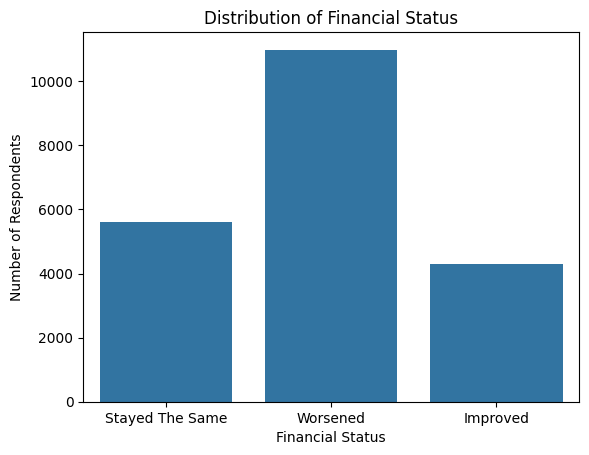

In [4]:
sns.countplot(
    data=financialaccess,
    x='financial_status',
)
plt.title('Distribution of Financial Status')
plt.xlabel('Financial Status')
plt.ylabel('Number of Respondents')

The target variable exhibits a clear class imbalance. More than half of respondents (52.6%) reported that their financial situation worsened. This imbalance creates a risk that a model may favour the majority class ("Worsened") at the expense of the minority classes. Consequently, weighted F1-score is more appropriate than accuracy because it evaluates performance across all classes while accounting for class frequencies.

### Monthly Income Distribution

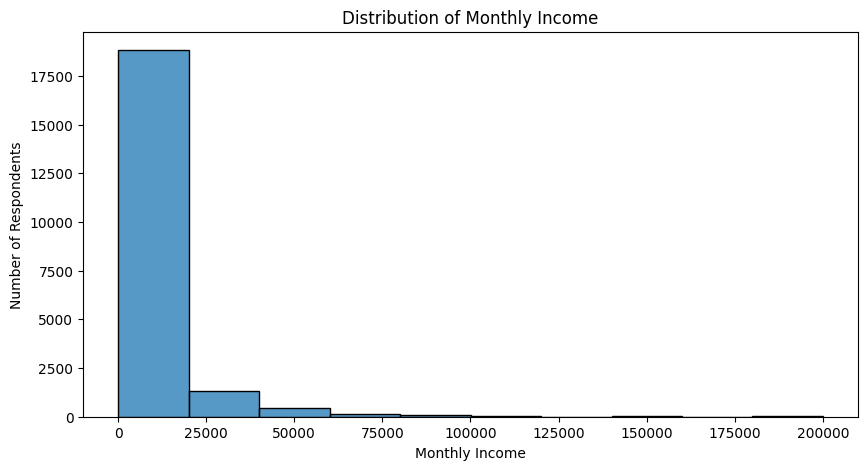

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    financialaccess['monthly_income'],
    bins = 10
)

plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Respondents")
plt.show()

The income distribution is strongly rightly-skewed. The majority of respondents are concentrated in the lower income ranges, suggesting that many households operate within limited financial resources.
This concentration in low income brackets is consistent with limited capacity for savings, emergency preparedness, and risk absorption across most of the sample, supporting the expectation that income will be associated with financial status.

### Income vs Financial Status


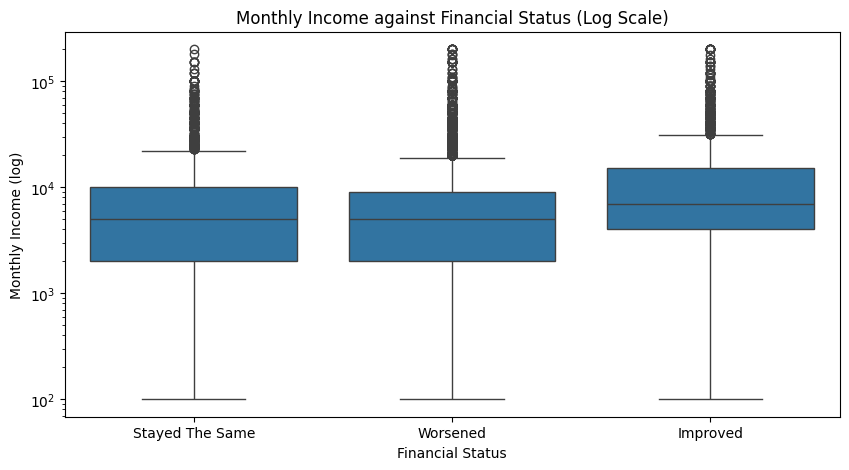

In [6]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=financialaccess,
    x='financial_status',
    y='monthly_income'
)

plt.yscale('log') 
plt.title("Monthly Income against Financial Status (Log Scale)")
plt.ylabel("Monthly Income (log)")
plt.xlabel("Financial Status")
plt.show()

The original hypothesis that lower income predicts "Worsened" status is only partially supported. A more accurate reading is that higher income is associated with reporting improvement, but income level doesn't meaningfully distinguish between people whose situation stayed stable versus those who declined. This suggests income alone is a weak discriminator for the majority of the income distribution, and that other factors (shocks, access to emergency funds, financial product usage) likely do more work in separating "Worsened" from "Stayed the same," while income may matter more specifically for moving up into "Improved".

This suggests that higher income acts as a protective factor against financial deterioration.

### Experienced Shock vs Financial Status

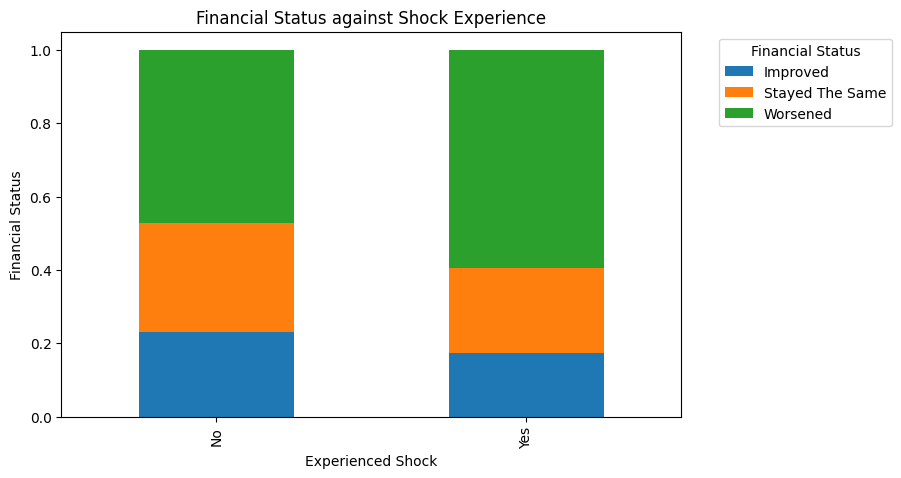

In [7]:
shock_table = pd.crosstab(
    financialaccess['experienced_shock'],
    financialaccess['financial_status'],
    normalize='index'
)

shock_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Financial Status against Shock Experience")
plt.legend(title="Financial Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Experienced Shock")
plt.ylabel("Financial Status")
plt.show()

A substantially larger proportion (difference of about 12%) of "Worsened" responses among individuals who experienced shocks provides evidence that shocks contribute directly to financial vulnerability. This pattern holds across the other two categories too: "Improved" drops slightly (from ~23% to ~18%) and "Stayed the same" drops more noticeably (from ~30% to ~23%) when shock was experienced.

Shock is therefore a more discriminating variable than monthly income.

### Access to Emergency Funds vs Financial Status

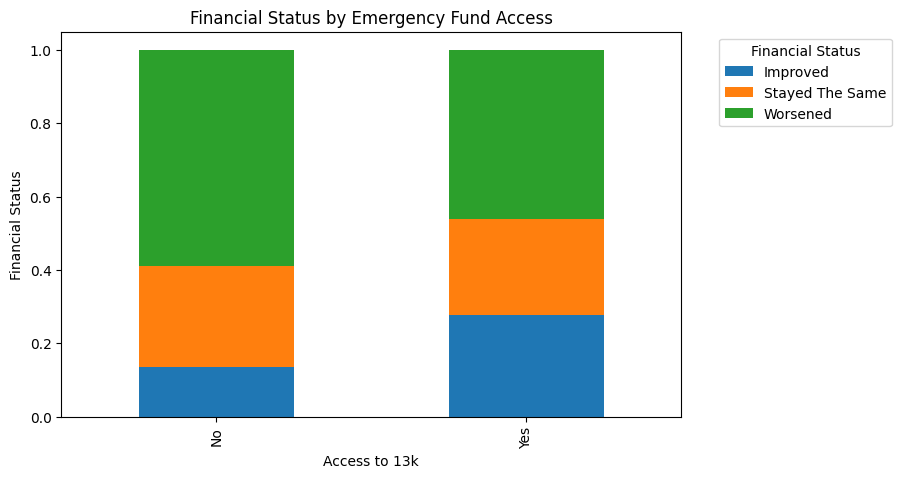

In [8]:
funds_table = pd.crosstab(
    financialaccess['accessto_13k_1month'],
    financialaccess['financial_status'],
    normalize='index'
)

funds_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Financial Status by Emergency Fund Access")
plt.xlabel("Access to 13k")
plt.ylabel("Financial Status")
plt.legend(title="Financial Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Majority of respondents with no access to KES 13,000 within one month reported "Worsened" financial status. This demonstrates that households/individuals unable to raise emergency funds are often financially fragile and may struggle to cope with unexpected expenses/financial shock. This variable captures preparedness rather than current income, making it a stronger measure of financial strength.

Coupled with Experienced Shock against Financial Status, it paints the picture that financial resilience determines financial status.

### Financial Literacy Score vs Financial Status

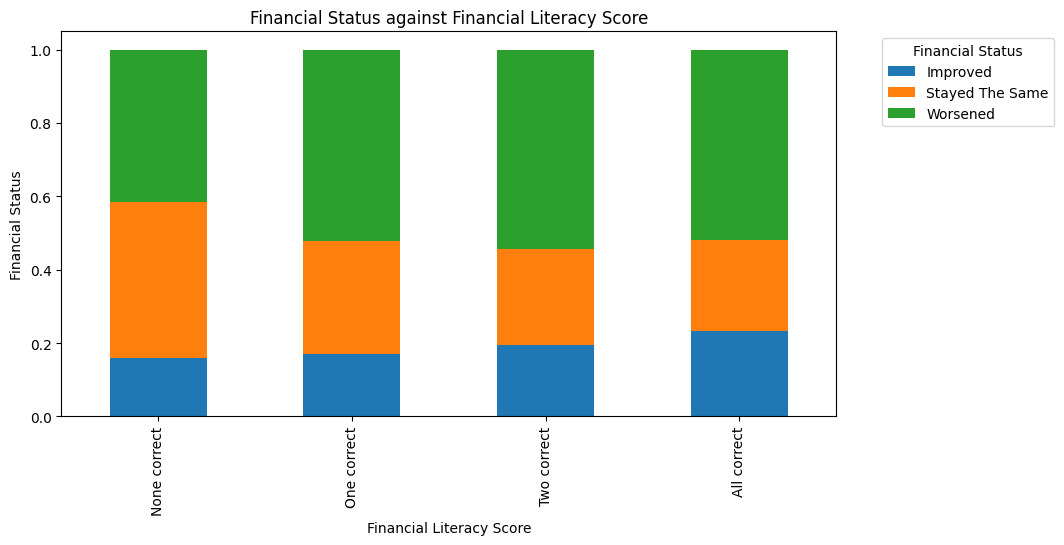

In [9]:
literacy_table = pd.crosstab(
    financialaccess['fl_score'],
    financialaccess['financial_status'],
    normalize='index'
)

order = ['None correct', 'One correct', 'Two correct', 'All correct']
literacy_table = literacy_table.reindex(order)

literacy_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Financial Status against Financial Literacy Score")
plt.xlabel("Financial Literacy Score")
plt.ylabel("Financial Status")
plt.legend(title="Financial Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The relationship between financial literacy and financial status appears weaker and less consistent than initially expected.
While respondents who answered all financial literacy questions correctly show a slightly higher proportion of improved financial outcomes, the relation does not change across those who answered one correct and two correct. In particular, respondents with no correct answers exhibit a lower share of worsening financial conditions and a higher share of stable outcomes than higher-scoring groups.

These findings suggest that financial literacy alone may not be a strong predictor of financial wellbeing. Knowledge of financial concepts does not necessarily translate into behaviours that improve financial resilience.

### Mobile Money Access vs Financial Status

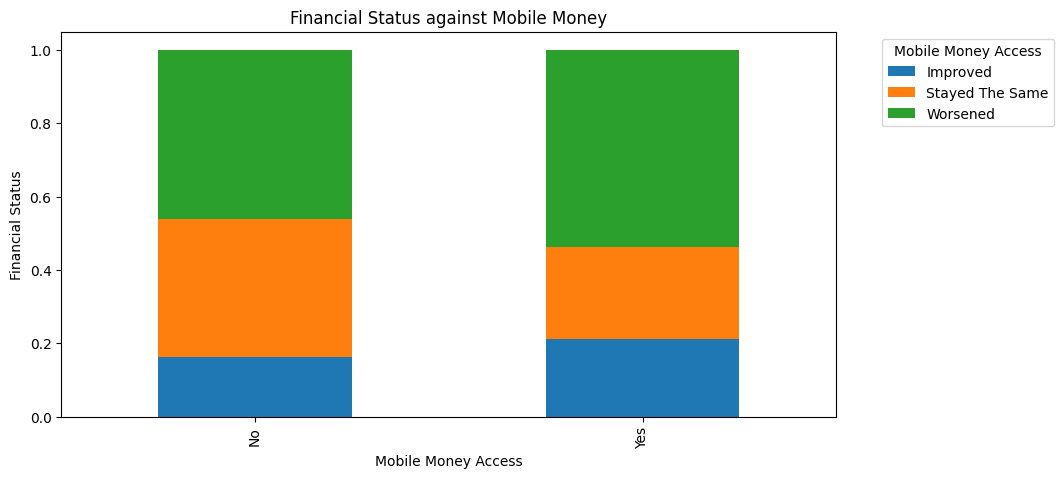

In [10]:
mobile_access_table = pd.crosstab(
    financialaccess['mobile_money_access'],
    financialaccess['financial_status'],
    normalize='index'
)

mobile_access_table.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Financial Status against Mobile Money")
plt.xlabel('Mobile Money Access')
plt.ylabel("Financial Status")
plt.legend(title="Mobile Money Access", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Respondents with mobile money access exhibit a slightly higher proportion of improved financial outcomes compared to those without access. However, they also show a higher proportion of worsening financial outcomes and a lower proportion of respondents whose financial situation remained unchanged.

One possible explanation is that mobile money access may be associated with greater participation in economic activity, exposing individuals to both opportunities for financial improvement and risks of financial decline. As a result, access itself may be less important than factors such as income stability, emergency preparedness, savings behaviour, and resilience to financial shocks.

Combined with the earlier findings on *Financial Status against Financial Literacy*, these findings indicate that access to financial tools alone may be insufficient to improve financial outcomes without complementary factors that strengthen financial resilience.

### Investigating relationship strength between Mobile Money Access and Financial Status

In [11]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    financialaccess['mobile_money_access'],
    financialaccess['financial_status']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 203.65940737083065
P-value: 5.96927511832731e-45


In [12]:
import numpy as np
from scipy.stats import chi2_contingency

table = pd.crosstab(
    financialaccess['mobile_money_access'],
    financialaccess['financial_status']
)

chi2 = chi2_contingency(table)[0]

n = table.sum().sum()

r, k = table.shape

cramers_v = np.sqrt(
    chi2 / (n * (min(r-1, k-1)))
)

print(cramers_v)

0.09878263548516598


A chi-square test found a statistically significant association between mobile money access and financial status (χ² = 203.66, p < 0.001).

However, the relationship was very weak (Cramér's V = 0.099), indicating that mobile money access explains little variation in financial outcomes.

While respondents with mobile money access reported slightly higher rates of financial improvement, they also reported higher rates of financial deterioration and lower rates of financial stability. This suggests that access to mobile money alone is not a strong predictor of financial wellbeing and may be less influential than factors such as shock exposure, emergency preparedness, and income.

### Key findings
* Financial shocks strongly associated with worsening outcomes.
* Emergency fund access strongly associated with better outcomes.
* Mobile money access has weak association.
* Financial literacy has inconsistent relationship.
* Income mainly separates "Improved" from the rest.

## Leakage Assessment
Leakage can artificially inflate model performance by allowing the model to learn information that is directly related to, or derived from, the target variable. As a result, evaluation metrics may appear strong during testing but fail to generalize to real-world scenarios.

Potentially problematic target-adjacent variables include:
* nfhi_11
* nfhi_12
* nfhi_13
* accessto_13k_1month
* not_difficult

These variables measure aspects of financial wellbeing, financial difficulty, and financial resilience that may overlap with the target variable (financial_status)

In [13]:
leakage_cols = [
    'nfhi_11',
    'nfhi_12',
    'nfhi_13',
    'accessto_13k_1month',
    'not_difficult'
]

for col in leakage_cols:
    
    print(f"\n{col}")
    
    display(
        pd.crosstab(
            financialaccess[col],
            financialaccess['financial_status'],
            normalize='index'
        )
    )


nfhi_11


financial_status,Improved,Stayed The Same,Worsened
nfhi_11,,,
No,0.140022,0.231559,0.628419
Yes,0.266474,0.303797,0.429728



nfhi_12


financial_status,Improved,Stayed The Same,Worsened
nfhi_12,,,
No,0.145917,0.226954,0.627129
Yes,0.241794,0.294638,0.463568



nfhi_13


financial_status,Improved,Stayed The Same,Worsened
nfhi_13,,,
No,0.170725,0.195337,0.633938
Yes,0.225306,0.311839,0.462855



accessto_13k_1month


financial_status,Improved,Stayed The Same,Worsened
accessto_13k_1month,,,
No,0.135748,0.276199,0.588053
Yes,0.277121,0.261010,0.461869



not_difficult


financial_status,Improved,Stayed The Same,Worsened
not_difficult,,,
No,0.177021,0.263635,0.559344
Yes,0.306352,0.287164,0.406484


### Findings
Cross-tabulation analysis showed that these variables were associated with financial status, with respondents reporting greater financial resilience generally more likely to experience stable or improving financial conditions.

However, none of the variables perfectly predicted the target variable, as respondents in each category were still distributed across all three financial status outcomes.

Therefore, the variables were retained for modelling, although their results should be interpreted with caution due to their close relationship with financial wellbeing.

## Feature Engineering
Three derived features are created based on patterns identified in the EDA and leakage assessment above.



### Income Bands
Monthly income was highly skewed, with a small number of respondents earning substantially more than the majority.

Income bands were created to improve interpretability and reduce the impact of extreme values.

In [14]:
financialaccess['income_band'] = pd.cut(
    financialaccess['monthly_income'],
    bins=[0, 2500, 5000, 10000, 25000, 200001],
    labels=[
        '0-2.5k',
        '2.5k-5k',
        '5k-10k',
        '10k-25k',
        '25k+'
    ]
)

### Resilience Score
Variables related to shock exposure, emergency fund access, and financial wellbeing were combined into a resilience score.

The score measures a respondent's ability to withstand financial challenges, with higher values indicating greater resilience.

<Axes: xlabel='resilience_score', ylabel='Count'>

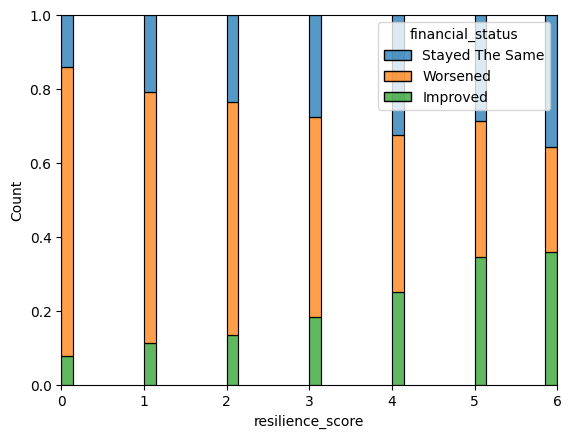

In [15]:
financialaccess['resilience_score'] = (
    (financialaccess['experienced_shock'] == 'No').astype(int)
    +
    (financialaccess['accessto_13k_1month'] == 'Yes').astype(int)
    +
    (financialaccess['nfhi_11'] == 'Yes').astype(int)
    +
    (financialaccess['nfhi_12'] == 'Yes').astype(int)
    +
    (financialaccess['nfhi_13'] == 'Yes').astype(int)
    +
    (financialaccess['not_difficult'] == 'Yes').astype(int)
)
financialaccess['resilience_score'].describe()

pd.crosstab(
    financialaccess['resilience_score'],
    financialaccess['financial_status'],
    normalize='index'
)

sns.histplot(
    data=financialaccess,
    x='resilience_score',
    hue='financial_status',
    multiple='fill'
) 

### Financial Access Score
A financial access score was constructed to measure the breadth of engagement with formal financial services.

This feature captures the access dimension of financial inclusion and allows comparison with the resilience score, which captures a household's ability to withstand financial shocks. 

In [16]:
financialaccess['financial_access_score'] = (
    (financialaccess['Savings_formal'] == 'Usage').astype(int)
    +
    (financialaccess['Loan_formal'] == 'Usage').astype(int)
    +
    (financialaccess['mobile_money_access'] == 'Yes').astype(int)
    +
    (financialaccess['formal_service_use'] == 'Usage').astype(int)
)

pd.crosstab(
    financialaccess['financial_access_score'],
    financialaccess['financial_status'],
    normalize='index'
)

financial_status,Improved,Stayed The Same,Worsened
financial_access_score,,,
0,0.160937,0.374386,0.464677
1,0.093960,0.476510,0.429530
2,0.152918,0.283870,0.563213
3,0.221255,0.240769,0.537977
4,0.267021,0.229400,0.503579


In [17]:
financialaccess.head(10)

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability,fl_score_num,income_band,resilience_score,financial_access_score
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,No,Stayed The Same,All correct,3,No barrier,Without Disability,3,25k+,5,2
1,Garissa,Urban,Female,55+,11,None,Married/Living with partner,10000,Non-usage,Non-usage,...,No,Worsened,Two correct,1,Affordability,Without Disability,2,5k-10k,2,2
2,Busia,Urban,Female,26-35,2,Primary completed,Divorced/separated,3000,Usage,Usage,...,No,Improved,All correct,5,Affordability,Without Disability,3,2.5k-5k,1,3
3,Kiambu,Urban,Male,18-25,1,Some secondary,Single/Never Married,10000,Usage,Non-usage,...,No,Improved,All correct,4,Affordability,Without Disability,3,5k-10k,2,4
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Improved,All correct,5,No barrier,Without Disability,3,5k-10k,6,4
5,Kilifi,Rural,Female,55+,3,Secondary completed,Married/Living with partner,4000,Non-usage,Non-usage,...,No,Worsened,All correct,2,Affordability,Without Disability,3,2.5k-5k,2,3
6,Meru,Rural,Female,36-45,6,Some primary,Single/Never Married,1000,Non-usage,Usage,...,No,Stayed The Same,All correct,4,Affordability,Without Disability,3,0-2.5k,2,2
7,Kilifi,Rural,Male,36-45,7,Some primary,Married/Living with partner,8500,Non-usage,Non-usage,...,No,Worsened,One correct,2,Affordability,Without Disability,1,5k-10k,2,3
8,Kisumu,Urban,Female,26-35,4,Primary completed,Married/Living with partner,1500,Usage,Non-usage,...,No,Worsened,Two correct,3,Affordability,Without Disability,2,0-2.5k,4,3
9,Baringo,Urban,Male,26-35,1,Secondary completed,Married/Living with partner,6500,Usage,Non-usage,...,No,Improved,All correct,12,No barrier,Without Disability,3,5k-10k,1,4


## Data Preprocessing
### Feature Selection
After creating the resilience score and financial access score, the individual variables used to construct these composite features were removed from the modelling dataset.

This was done to reduce redundancy and improve interpretability.

### Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data.

A stratified split was used to preserve the original distribution of the target variable across both datasets. This is particularly important because the target classes are imbalanced, with over half of respondents reporting a worsening financial situation.

Eighty percent of the data was allocated to training and twenty percent to testing.

In [18]:
import pandas as pd
import numpy as np

# Work on a copy
df_base = financialaccess.copy()

df_base['barriers_bank'] = df_base['barriers_bank'].fillna('No barrier')
obj_cols = df_base.select_dtypes(include='object').columns
df_base[obj_cols] = df_base[obj_cols].apply(lambda s: s.str.strip())

# Feature Engineering
df_base['income_band'] = pd.cut(
    df_base['monthly_income'],
    bins=[0, 2500, 5000, 10000, 25000, 200001],
    labels=['0-2.5k', '2.5k-5k', '5k-10k', '10k-25k', '25k+']
)

df_base['resilience_score'] = (
    (df_base['experienced_shock'] == 'No').astype(int) +
    (df_base['accessto_13k_1month'] == 'Yes').astype(int) +
    (df_base['nfhi_11'] == 'Yes').astype(int) +
    (df_base['nfhi_12'] == 'Yes').astype(int) +
    (df_base['nfhi_13'] == 'Yes').astype(int) +
    (df_base['not_difficult'] == 'Yes').astype(int)
)

df_base['financial_access_score'] = (
    (df_base['Savings_formal'] == 'Usage').astype(int) +
    (df_base['Loan_formal'] == 'Usage').astype(int) +
    (df_base['mobile_money_access'] == 'Yes').astype(int) +
    (df_base['formal_service_use'] == 'Usage').astype(int)
)

df_base['shock_no_buffer'] = (
    (df_base['experienced_shock'] == 'Yes') &
    (df_base['accessto_13k_1month'] == 'No')
).astype(int)

#Drop columns not used as model features
drop_cols = [
    'county', 'monthly_income', 'education_level',
    'experienced_shock', 'accessto_13k_1month',
    'nfhi_11', 'nfhi_12', 'nfhi_13', 'not_difficult',
    'Savings_formal', 'Loan_formal', 'mobile_money_access', 'formal_service_use'
]
df_base = df_base.drop(columns=drop_cols)

#Target encoding
print(df_base['financial_status'].unique())  # run this first, copy the exact strings below

target_map = {
    'Worsened': 0,
    'Stayed The Same': 1,   # match exact casing from .unique() output
    'Improved': 2
}
df_base['financial_status'] = financialaccess['financial_status'].str.strip().map(target_map)

print(df_base['financial_status'].isnull().sum())  # should be 0 before proceeding


print(df_base.shape)
print(df_base.dtypes)


['Stayed The Same' 'Worsened' 'Improved']
0
(20871, 20)
location_type               object
Sex                         object
Age                         object
household_size               int64
marital_status              object
Savings_informal            object
Loan_informal               object
defaulted                   object
barriers_mobile_money       object
mobile_ownership_1          object
financial_status             int64
fl_score                    object
prodsum1                     int64
barriers_bank               object
has_disability              object
fl_score_num                 int64
income_band               category
resilience_score             int64
financial_access_score       int64
shock_no_buffer              int64
dtype: object


The dataset was split into training and testing sets using an 80:20 ratio.

Stratified sampling was applied to preserve the original distribution of financial status categories in both datasets. This ensures that the model is evaluated on a representative sample of respondents and helps address the class imbalance present in the target variable.

## Model Development
### Logistic Regression
Logistic Regression was used as a baseline model due to its interpretability and ability to establish a benchmark for more complex algorithms.

In [19]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

df_lr = df_base.copy()

# Ordinal-encode genuinely ordinal columns, preserves order, keeps coefficients interpretable
age_order = [
    '16-17',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '55+'
]     
fl_order = ['None correct', 'One correct', 'Two correct', 'All correct']

oe_lr = OrdinalEncoder(categories=[age_order, fl_order])
df_lr[['Age', 'fl_score']] = oe_lr.fit_transform(df_lr[['Age', 'fl_score']])

# One-hot encode remaining nominal categoricals
df_lr = pd.get_dummies(df_lr, drop_first=True)

X_lr = df_lr.drop(columns=['financial_status'])
y_lr = df_lr['financial_status']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.20, random_state=42, stratify=y_lr
)

# Scale
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_lr_scaled, y_train_lr)
y_pred_lr = lr.predict(X_test_lr_scaled)

f1_lr = f1_score(y_test_lr, y_pred_lr, average='weighted')
print(f"Logistic Regression Weighted F1: {f1_lr:.3f}")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Worsened','Stayed the same','Improved']))

Logistic Regression Weighted F1: 0.500
                 precision    recall  f1-score   support

       Worsened       0.68      0.56      0.61      2197
Stayed the same       0.38      0.33      0.35      1122
       Improved       0.33      0.55      0.41       856

       accuracy                           0.49      4175
      macro avg       0.46      0.48      0.46      4175
   weighted avg       0.53      0.49      0.50      4175



### Random Forest
A Random Forest classifier was trained to evaluate whether an ensemble of decision trees could improve predictive performance compared to a single Decision Tree.

Random Forest reduces overfitting by combining predictions from multiple trees built on different subsets of the data and features. This enables the model to capture more complex relationships while generally providing better generalization than an individual tree.

In [20]:
from sklearn.ensemble import RandomForestClassifier

df_rf = df_base.copy()

# one-hot encode everything categorical
df_rf = pd.get_dummies(df_rf, drop_first=True)

X_rf = df_rf.drop(columns=['financial_status'])
y_rf = df_rf['financial_status']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.20, random_state=42, stratify=y_rf
)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=42
)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

f1_rf = f1_score(y_test_rf, y_pred_rf, average='weighted')
print(f"Random Forest Weighted F1: {f1_rf:.3f}")
print(classification_report(y_test_rf, y_pred_rf, target_names=['Worsened','Stayed the same','Improved']))

Random Forest Weighted F1: 0.505
                 precision    recall  f1-score   support

       Worsened       0.67      0.59      0.63      2197
Stayed the same       0.39      0.31      0.35      1122
       Improved       0.33      0.52      0.40       856

       accuracy                           0.50      4175
      macro avg       0.46      0.47      0.46      4175
   weighted avg       0.52      0.50      0.51      4175



### XGBoost

XGBoost (Extreme Gradient Boosting) was implemented to capture complex, non-linear relationships between respondent characteristics and financial status.

Unlike a single decision tree, XGBoost builds an ensemble of trees sequentially, where each new tree focuses on correcting errors made by previous trees. This approach often produces strong predictive performance on structured tabular data while remaining capable of identifying important feature interactions.

In [21]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

df_xgb = df_base.copy()

df_xgb = pd.get_dummies(df_xgb, drop_first=True)

X_xgb = df_xgb.drop(columns=['financial_status'])
y_xgb = df_xgb['financial_status']

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.20, random_state=42, stratify=y_xgb
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mlogloss'
)
xgb.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test_xgb)
print(f1_score(y_test_xgb, y_pred_xgb, average='weighted'))

f1_xgb = f1_score(y_test_xgb, y_pred_xgb, average='weighted')
print(f"XGBoost Weighted F1: {f1_xgb:.3f}")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=['Worsened','Stayed the same','Improved']))

0.5054672845615454
XGBoost Weighted F1: 0.505
                 precision    recall  f1-score   support

       Worsened       0.67      0.59      0.63      2197
Stayed the same       0.39      0.30      0.34      1122
       Improved       0.34      0.53      0.41       856

       accuracy                           0.50      4175
      macro avg       0.46      0.47      0.46      4175
   weighted avg       0.52      0.50      0.51      4175



## Comparison Table

In [22]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Weighted F1': [f1_lr, f1_rf, f1_xgb]
})
print(comparison)

                 Model  Weighted F1
0  Logistic Regression     0.500437
1        Random Forest     0.505033
2              XGBoost     0.505467


### Why Model Performance Converged Around 0.50 Weighted F1

The similar performance achieved by Logistic Regression, Random Forest, and XGBoost suggests that the limitation lies in the dataset's predictive signal rather than the choice of algorithm.



One reason is that financial_status is a subjective, self-reported measure. Respondents evaluate whether their financial situation improved, stayed the same, or worsened based on personal experiences and perceptions, many of which are not captured in the survey data.



Additionally, the exploratory analysis found that no single variable strongly separated the three outcome classes. While factors such as resilience, emergency fund access, and financial wellbeing showed meaningful relationships with financial status, substantial overlap remained across all categories.



The small performance gap between linear and tree-based models further suggests that the relationships in the data are relatively modest and do not contain strong non-linear patterns that more complex models can exploit.



Overall, the results indicate that financial status is influenced by a combination of demographic, behavioural, and resilience-related factors rather than a single dominant predictor

## Feature Importance

In [23]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,resilience_score,0.084217
16,marital_status_Single/Never Married,0.049493
4,financial_access_score,0.044676
8,Age_18-25,0.043851
46,income_band_25k+,0.040789
33,barriers_bank_Affordability,0.033568
36,barriers_bank_Eligibility,0.031053
45,income_band_10k-25k,0.030995
12,Age_55+,0.028674
30,fl_score_None correct,0.025611


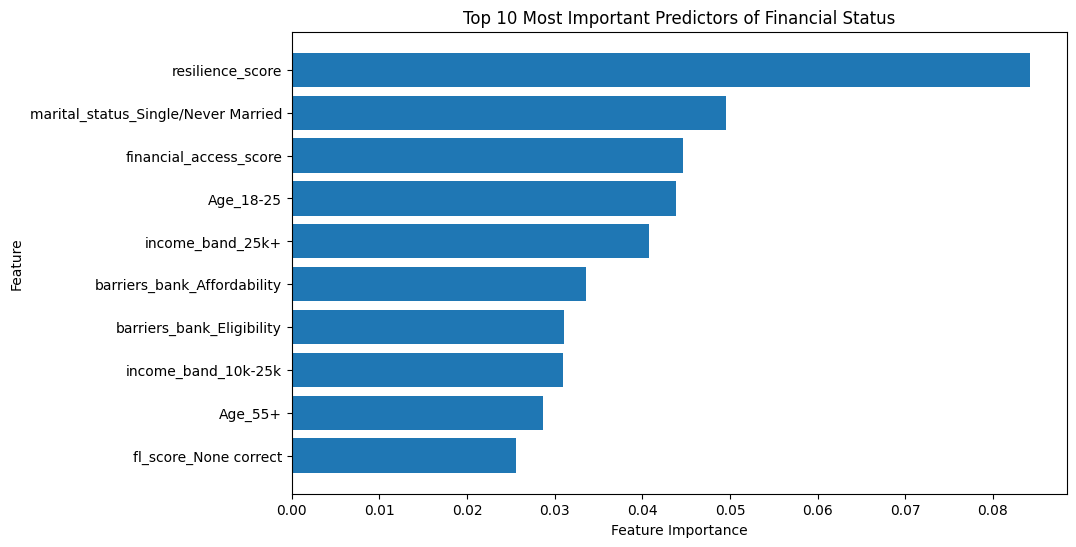

In [24]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Predictors of Financial Status')
plt.gca().invert_yaxis()
plt.show()